<a href="https://colab.research.google.com/github/GourieG/GenAI-Internship/blob/main/preprocessing_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder

In [2]:
df=pd.read_csv("/content/preprocessing_practice_dataset.csv")

In [3]:
df.describe()

,Employee_ID,Age,Experience_Years,Monthly_Salary,Performance_Rating
count,100.000000,90.000000,100.000000,90.000000,100.000000
mean,1050.500000,39.866667,9.360000,75111.988889,3.230000
std,29.011492,11.015005,6.210971,28068.924984,1.476106
min,1001.000000,21.000000,0.000000,25412.000000,1.000000
25%,1025.750000,29.250000,4.000000,50536.250000,2.000000
50%,1050.500000,41.000000,10.000000,72715.500000,4.000000
75%,1075.250000,48.000000,15.000000,99079.000000,5.000000
max,1100.000000,59.000000,19.000000,119297.000000,5.000000


In [5]:
df.isnull().sum()

,0
Employee_ID,0
Age,10
Gender,0
Department,10
Education,10
Experience_Years,0
Monthly_Salary,10
Performance_Rating,0
City,10
Attrition,0


In [8]:
df['Age_mean']=df['Age'].fillna(df['Age'].mean())
df['Salary_median']=df['Monthly_Salary'].fillna(df['Monthly_Salary'].median())
df['Education_mode']=df['Education'].fillna(df['Education'].mode()[0])
df['City_mode']=df['City'].fillna(df['City'].mode()[0])

df

,Employee_ID,Age,Gender,Department,Education,Experience_Years,Monthly_Salary,Performance_Rating,City,Attrition,Age_mean,Age_median,Salary_median,Education_mode,City_mode
0,1001,59.0,Male,HR,Masters,18,52350.0,5,Calicut,No,59.0,59.0,52350.0,Masters,Calicut
1,1002,49.0,Female,Marketing,Bachelors,16,118008.0,2,Chennai,Yes,49.0,49.0,118008.0,Bachelors,Chennai
2,1003,35.0,Female,HR,NaN,19,119297.0,1,Kochi,Yes,35.0,35.0,119297.0,Masters,Kochi
3,1004,28.0,Female,HR,PhD,9,50351.0,2,Trivandrum,Yes,28.0,28.0,50351.0,PhD,Trivandrum
4,1005,41.0,Male,IT,Bachelors,5,113668.0,3,Trivandrum,Yes,41.0,41.0,113668.0,Bachelors,Trivandrum
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,1096,54.0,Female,HR,Masters,11,48625.0,5,Chennai,Yes,54.0,54.0,48625.0,Masters,Chennai
96,1097,53.0,Male,Marketing,Masters,13,107873.0,5,Trivandrum,Yes,53.0,53.0,107873.0,Masters,Trivandrum
97,1098,43.0,Male,NaN,PhD,1,97592.0,3,Chennai,No,43.0,43.0,97592.0,PhD,Chennai
98,1099,44.0,Female,Marketing,PhD,18,102052.0,5,Calicut,Yes,44.0,44.0,102052.0,PhD,Calicut


In [9]:
sns.set(style='whitegrid')

/tmp/ipykernel_2855/3352773166.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,x="Age",y="Department",palette='pastel')


Text(0, 0.5, 'Department')

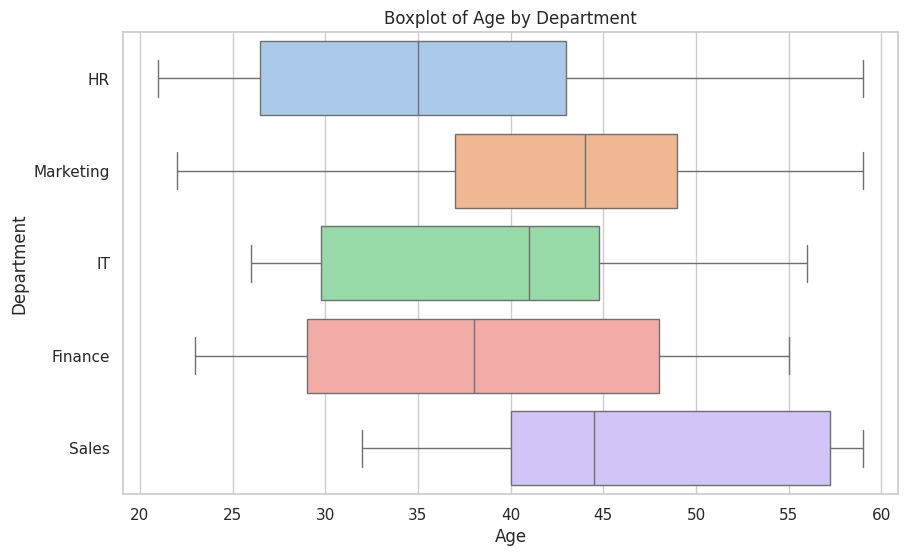

In [14]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df,x="Age",y="Department",palette='pastel')
plt.title('Boxplot of Age by Department')
plt.xlabel('Age',fontsize=12)
plt.ylabel('Department',fontsize=12)

/tmp/ipykernel_2855/1164330560.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=df,x="Age",y="Department",palette='pastel')


Text(0, 0.5, 'Department')

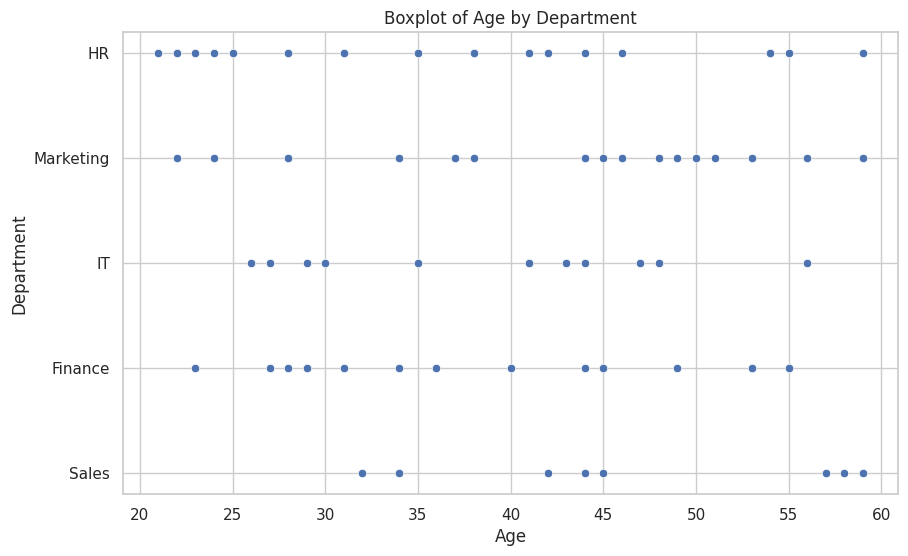

In [15]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df,x="Age",y="Department",palette='pastel')
plt.title('Boxplot of Age by Department')
plt.xlabel('Age',fontsize=12)
plt.ylabel('Department',fontsize=12)

/tmp/ipykernel_2855/1247505737.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(data=df,x="Age",y="Department",palette='pastel')


Text(0, 0.5, 'Department')

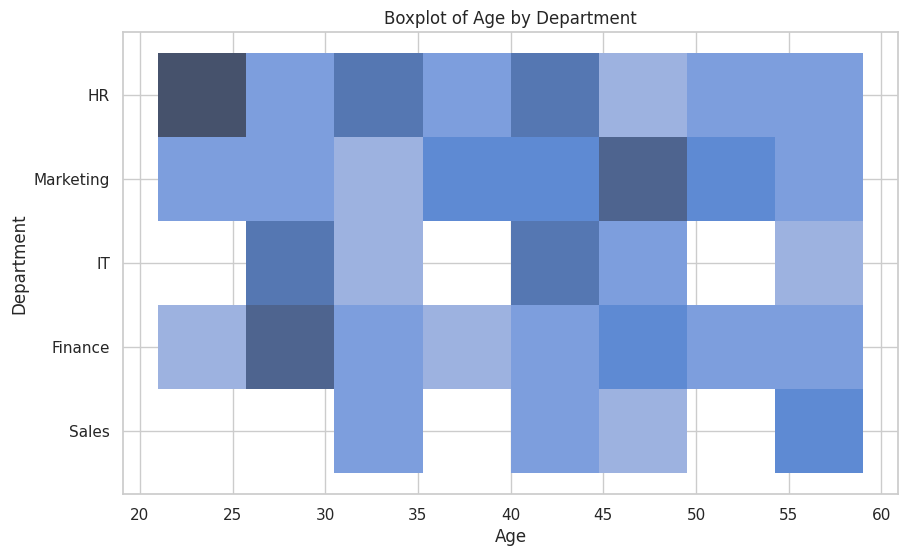

In [16]:
plt.figure(figsize=(10,6))
sns.histplot(data=df,x="Age",y="Department",palette='pastel')
plt.title('Boxplot of Age by Department')
plt.xlabel('Age',fontsize=12)
plt.ylabel('Department',fontsize=12)

/tmp/ipykernel_2855/461636271.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(data=df,x="Age",y="Department",palette='pastel')


Text(0, 0.5, 'Department')

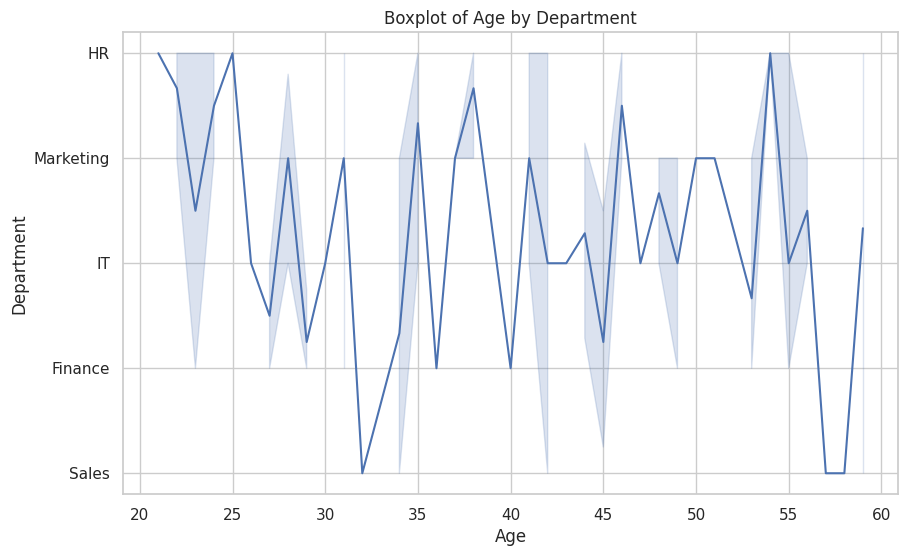

In [17]:
plt.figure(figsize=(10,6))
sns.lineplot(data=df,x="Age",y="Department",palette='pastel')
plt.title('Boxplot of Age by Department')
plt.xlabel('Age',fontsize=12)
plt.ylabel('Department',fontsize=12)

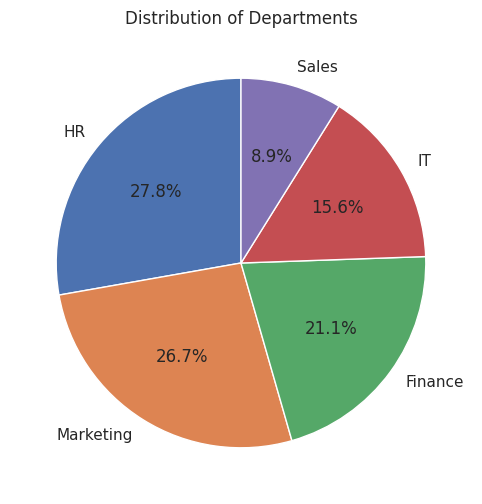

In [25]:
plt.figure(figsize=(10,6))
department_counts = df['Department'].value_counts()
plt.pie(department_counts, labels=department_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Departments')
plt.ylabel('') # Remove y-label as it's not applicable for pie charts
plt.show()

In [26]:
encoded_data=df.copy()

In [39]:
label_encoder=LabelEncoder()
encoded_data['Gender_Label']=label_encoder.fit_transform(encoded_data['Gender'])

onehot_encoded=pd.get_dummies(encoded_data['Department'],prefix='Department')
onehot_encoded=pd.get_dummies(encoded_data['City'],prefix='City')
encoded_data=pd.concat([encoded_data,onehot_encoded],axis=1)
encoded_data



,Employee_ID,Age,Gender,Department,Education,Experience_Years,Monthly_Salary,Performance_Rating,City,Attrition,...,City_Bangalore,City_Calicut,City_Chennai,City_Kochi,City_Trivandrum,City_Bangalore,City_Calicut,City_Chennai,City_Kochi,City_Trivandrum
0,1001,59.0,Male,HR,Masters,18,52350.0,5,Calicut,No,...,False,True,False,False,False,False,True,False,False,False
1,1002,49.0,Female,Marketing,Bachelors,16,118008.0,2,Chennai,Yes,...,False,False,True,False,False,False,False,True,False,False
2,1003,35.0,Female,HR,NaN,19,119297.0,1,Kochi,Yes,...,False,False,False,True,False,False,False,False,True,False
3,1004,28.0,Female,HR,PhD,9,50351.0,2,Trivandrum,Yes,...,False,False,False,False,True,False,False,False,False,True
4,1005,41.0,Male,IT,Bachelors,5,113668.0,3,Trivandrum,Yes,...,False,False,False,False,True,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,1096,54.0,Female,HR,Masters,11,48625.0,5,Chennai,Yes,...,False,False,True,False,False,False,False,True,False,False
96,1097,53.0,Male,Marketing,Masters,13,107873.0,5,Trivandrum,Yes,...,False,False,False,False,True,False,False,False,False,True
97,1098,43.0,Male,NaN,PhD,1,97592.0,3,Chennai,No,...,False,False,True,False,False,False,False,True,False,False
98,1099,44.0,Female,Marketing,PhD,18,102052.0,5,Calicut,Yes,...,False,True,False,False,False,False,True,False,False,False


In [42]:
numerical_columns=['Age','Monthly_Salary']

minmax_scaler=MinMaxScaler()
standard_scaler=StandardScaler()
df['Age_MinMax']  =minmax_scaler.fit_transform(df[['Age']])
df['Monthly_Salary_MinMax'] =minmax_scaler.fit_transform(df[['Monthly_Salary']])
df['Age_Standard'] =standard_scaler.fit_transform(df[['Age']])
df['Monthly_Salary_Standard'] =standard_scaler.fit_transform(df[['Monthly_Salary']])
df

,Employee_ID,Age,Gender,Department,Education,Experience_Years,Monthly_Salary,Performance_Rating,City,Attrition,Age_mean,Age_median,Salary_median,Education_mode,City_mode,Age_MinMax,Monthly_Salary_MinMax,Age_Standard,Monthly_Salary_Standard
0,1001,59.0,Male,HR,Masters,18,52350.0,5,Calicut,No,59.0,59.0,52350.0,Masters,Calicut,1.000000,0.286925,1.746756,-0.815475
1,1002,49.0,Female,Marketing,Bachelors,16,118008.0,2,Chennai,Yes,49.0,49.0,118008.0,Bachelors,Chennai,0.736842,0.986270,0.833817,1.536800
2,1003,35.0,Female,HR,NaN,19,119297.0,1,Kochi,Yes,35.0,35.0,119297.0,Masters,Kochi,0.368421,1.000000,-0.444297,1.582980
3,1004,28.0,Female,HR,PhD,9,50351.0,2,Trivandrum,Yes,28.0,28.0,50351.0,PhD,Trivandrum,0.184211,0.265633,-1.083354,-0.887092
4,1005,41.0,Male,IT,Bachelors,5,113668.0,3,Trivandrum,Yes,41.0,41.0,113668.0,Bachelors,Trivandrum,0.526316,0.940044,0.103466,1.381314
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,1096,54.0,Female,HR,Masters,11,48625.0,5,Chennai,Yes,54.0,54.0,48625.0,Masters,Chennai,0.868421,0.247249,1.290286,-0.948928
96,1097,53.0,Male,Marketing,Masters,13,107873.0,5,Trivandrum,Yes,53.0,53.0,107873.0,Masters,Trivandrum,0.842105,0.878319,1.198993,1.173702
97,1098,43.0,Male,NaN,PhD,1,97592.0,3,Chennai,No,43.0,43.0,97592.0,PhD,Chennai,0.578947,0.768813,0.286054,0.805373
98,1099,44.0,Female,Marketing,PhD,18,102052.0,5,Calicut,Yes,44.0,44.0,102052.0,PhD,Calicut,0.605263,0.816318,0.377348,0.965158
